In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [100]:
import pandas as pd

# Load CSV files
orders = pd.read_csv("data/olist_orders_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
customers = pd.read_csv("data/olist_customers_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")

print("All main CSV files loaded successfully!")

All main CSV files loaded successfully!


In [101]:
# Display first 5 rows of each dataset

print("========== ORDERS ==========")
display(orders.head())

print("========== ORDER ITEMS ==========")
display(order_items.head())

print("========== CUSTOMERS ==========")
display(customers.head())

print("========== PRODUCTS ==========")
display(products.head())

print("========== REVIEWS ==========")
display(reviews.head())

print("========== PAYMENTS ==========")
display(payments.head())

========== ORDERS ==========


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


========== ORDER ITEMS ==========


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


========== CUSTOMERS ==========


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


========== REVIEWS ==========


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


========== PAYMENTS ==========


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [102]:
print("Orders Columns:")
print(orders.columns.tolist())

print("\nOrder Items Columns:")
print(order_items.columns.tolist())

print("\nCustomers Columns:")
print(customers.columns.tolist())

print("\nProducts Columns:")
print(products.columns.tolist())

print("\nReviews Columns:")
print(reviews.columns.tolist())

print("\nPayments Columns:")
print(payments.columns.tolist())

Orders Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Order Items Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Customers Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Products Columns:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Reviews Columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Payments Columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


In [103]:
print("ORDERS DATA TYPES")
print(orders.dtypes)

print("\nORDER ITEMS DATA TYPES")
print(order_items.dtypes)

print("\nCUSTOMERS DATA TYPES")
print(customers.dtypes)

print("\nPRODUCTS DATA TYPES")
print(products.dtypes)

print("\nREVIEWS DATA TYPES")
print(reviews.dtypes)

print("\nPAYMENTS DATA TYPES")
print(payments.dtypes)

ORDERS DATA TYPES
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

ORDER ITEMS DATA TYPES
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

CUSTOMERS DATA TYPES
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

PRODUCTS DATA TYPES
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64


In [104]:
datasets = {
    "Orders": orders,
    "Order Items": order_items,
    "Customers": customers,
    "Products": products,
    "Reviews": reviews,
    "Payments": payments
}

for name, df in datasets.items():
    print("\n==========", name, "==========")
    print(df.isnull().sum())


========== Orders ==========
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

========== Order Items ==========
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

========== Customers ==========
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

========== Products ==========
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                

In [105]:
for name, df in datasets.items():
    print(name, "duplicates:", df.duplicated().sum())

Orders duplicates: 0
Order Items duplicates: 0
Customers duplicates: 0
Products duplicates: 0
Reviews duplicates: 0
Payments duplicates: 0


In [106]:
# Convert order date columns into datetime format

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

print("Date columns converted successfully!")

Date columns converted successfully!


In [107]:
print(orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [108]:
orders["shipping_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

print(orders[["order_id", "shipping_days"]].head(10))

                           order_id  shipping_days
0  e481f51cbdc54678b7cc49136f2d6af7            8.0
1  53cdb2fc8bc7dce0b6741e2150273451           13.0
2  47770eb9100c2d0c44946d9cf07ec65d            9.0
3  949d5b44dbf5de918fe9c16f97b45f8a           13.0
4  ad21c59c0840e6cb83a9ceb5573f8159            2.0
5  a4591c265e18cb1dcee52889e2d8acc3           16.0
6  136cce7faa42fdb2cefd53fdc79a6098            NaN
7  6514b8ad8028c9f2cc2374ded245783f            9.0
8  76c6e866289321a7c93b82b54852dc33            9.0
9  e69bfb5eb88e0ed6a785585b27e16dbf           18.0


In [109]:
# Check shipping days for invalid values

print("Minimum shipping days:", orders["shipping_days"].min())
print("Maximum shipping days:", orders["shipping_days"].max())
print("Missing shipping days:", orders["shipping_days"].isnull().sum())

# Check negative shipping days
negative_shipping = orders[orders["shipping_days"] < 0]

print("Negative shipping days:", len(negative_shipping))

Minimum shipping days: 0.0
Maximum shipping days: 209.0
Missing shipping days: 2965
Negative shipping days: 0


In [110]:
# Calculate total value for each order

order_items["item_total"] = (
    order_items["price"] +
    order_items["freight_value"]
)

order_value = (
    order_items
    .groupby("order_id")["item_total"]
    .sum()
    .reset_index()
)

order_value.columns = ["order_id", "order_value"]

print("Order value calculated successfully!")

display(order_value.head())

Order value calculated successfully!


,order_id,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [52]:
def calculate_order_value(data):
    """
    Calculate total order value including freight.
    """
    data = data.copy()
    
    data["item_total"] = (
        data["price"] +
        data["freight_value"]
    )
    
    result = (
        data.groupby("order_id")["item_total"]
        .sum()
        .reset_index()
    )
    
    result.columns = ["order_id", "order_value"]
    
    return result


# Use the function
order_value = calculate_order_value(order_items)

print("Function executed successfully!")
display(order_value.head())

Function executed successfully!


,order_id,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [53]:
orders = orders.merge(
    order_value,
    on="order_id",
    how="left"
)

print("Order value merged with orders successfully!")

display(
    orders[
        [
            "order_id",
            "order_status",
            "order_purchase_timestamp",
            "shipping_days",
            "order_value"
        ]
    ].head(10)
)

Order value merged with orders successfully!


,order_id,order_status,order_purchase_timestamp,shipping_days,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,8.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,13.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,9.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,13.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2.0,28.62
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,2017-07-09 21:57:05,16.0,175.26
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,2017-04-11 12:22:08,NaN,65.95
7,6514b8ad8028c9f2cc2374ded245783f,delivered,2017-05-16 13:10:30,9.0,75.16
8,76c6e866289321a7c93b82b54852dc33,delivered,2017-01-23 18:29:09,9.0,35.95
9,e69bfb5eb88e0ed6a785585b27e16dbf,delivered,2017-07-29 11:55:02,18.0,169.76


In [54]:
# Merge orders with customer information

orders_customers = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

print("Orders and Customers merged successfully!")

print("Shape:", orders_customers.shape)

display(
    orders_customers[
        [
            "order_id",
            "customer_id",
            "customer_unique_id",
            "order_status",
            "order_value"
        ]
    ].head(10)
)

Orders and Customers merged successfully!
Shape: (99441, 14)


,order_id,customer_id,customer_unique_id,order_status,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,28.62
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,80bb27c7c16e8f973207a5086ab329e2,delivered,175.26
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,36edbb3fb164b1f16485364b6fb04c73,invoiced,65.95
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,932afa1e708222e5821dac9cd5db4cae,delivered,75.16
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,39382392765b6dc74812866ee5ee92a7,delivered,35.95
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,299905e3934e9e181bfb2e164dd4b4f8,delivered,169.76


In [55]:
# Merge order items with product information

items_products = order_items.merge(
    products,
    on="product_id",
    how="left"
)

print("Order Items and Products merged successfully!")

print("Shape:", items_products.shape)

display(
    items_products[
        [
            "order_id",
            "product_id",
            "price",
            "freight_value",
            "product_category_name"
        ]
    ].head(10)
)

Order Items and Products merged successfully!
Shape: (112650, 16)


,order_id,product_id,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,18.14,ferramentas_jardim
5,00048cc3ae777c65dbb7d2a0634bc1ea,ef92defde845ab8450f9d70c526ef70f,21.90,12.69,utilidades_domesticas
6,00054e8431b9d7675808bcb819fb4a32,8d4f2bb7e93e6710a28f34fa83ee7d28,19.90,11.85,telefonia
7,000576fe39319847cbb9d288c5617fa6,557d850972a7d6f792fd18ae1400d9b6,810.00,70.75,ferramentas_jardim
8,0005a1a1728c9d785b8e2b08b904576c,310ae3c140ff94b03219ad0adc3c778f,145.95,11.65,beleza_saude
9,0005f50442cb953dcd1d21e1fb923495,4535b0e1091c278dfd193e5a1d63b39f,53.99,11.40,livros_tecnicos


In [56]:
# Load category translation file

category_translation = pd.read_csv(
    "data/product_category_name_translation.csv"
)

print("Category translation file loaded successfully!")

display(category_translation.head())

Category translation file loaded successfully!


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [57]:
# Merge English category names

items_products = items_products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

print("Category translation merged successfully!")

display(
    items_products[
        [
            "product_category_name",
            "product_category_name_english"
        ]
    ].head(10)
)

Category translation merged successfully!


,product_category_name,product_category_name_english
0,cool_stuff,cool_stuff
1,pet_shop,pet_shop
2,moveis_decoracao,furniture_decor
3,perfumaria,perfumery
4,ferramentas_jardim,garden_tools
5,utilidades_domesticas,housewares
6,telefonia,telephony
7,ferramentas_jardim,garden_tools
8,beleza_saude,health_beauty
9,livros_tecnicos,books_technical


In [58]:
# Check missing review scores

print("Missing review scores:")
print(reviews["review_score"].isnull().sum())

print("\nReview score distribution:")
print(reviews["review_score"].value_counts().sort_index())

Missing review scores:
0

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [59]:
# Fill missing review scores with median

median_review_score = reviews["review_score"].median()

reviews["review_score"] = reviews["review_score"].fillna(
    median_review_score
)

print("Missing review scores handled successfully!")
print("Median review score used:", median_review_score)
print("Remaining missing values:",
      reviews["review_score"].isnull().sum())

Missing review scores handled successfully!
Median review score used: 5.0
Remaining missing values: 0


In [60]:
# Merge reviews with orders

orders_reviews = orders.merge(
    reviews[
        [
            "order_id",
            "review_score",
            "review_comment_message"
        ]
    ],
    on="order_id",
    how="left"
)

print("Orders and Reviews merged successfully!")

print("Shape:", orders_reviews.shape)

display(
    orders_reviews[
        [
            "order_id",
            "order_status",
            "order_value",
            "shipping_days",
            "review_score"
        ]
    ].head(10)
)

Orders and Reviews merged successfully!
Shape: (99992, 12)


,order_id,order_status,order_value,shipping_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,38.71,8.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,141.46,13.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,179.12,9.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,72.20,13.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,28.62,2.0,5.0
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,175.26,16.0,4.0
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,65.95,NaN,2.0
7,6514b8ad8028c9f2cc2374ded245783f,delivered,75.16,9.0,5.0
8,76c6e866289321a7c93b82b54852dc33,delivered,35.95,9.0,1.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,delivered,169.76,18.0,5.0


In [61]:
# Merge customer information with orders

orders_with_customers = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

# Count orders for each unique customer

customer_orders = (
    orders_with_customers
    .groupby("customer_unique_id")["order_id"]
    .count()
    .reset_index()
)

customer_orders.columns = [
    "customer_unique_id",
    "order_count"
]

display(customer_orders.head(10))

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
5,0004bd2a26a76fe21f786e4fbd80607f,1
6,00050ab1314c0e55a6ca13cf7181fecf,1
7,00053a61a98854899e70ed204dd4bafe,1
8,0005e1862207bf6ccc02e4228effd9a0,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1


In [62]:
# Calculate repeat customer rate

total_customers = len(customer_orders)

repeat_customers = (
    customer_orders["order_count"] > 1
).sum()

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

print("Total customers:", total_customers)
print("Repeat customers:", repeat_customers)
print(
    "Repeat customer rate:",
    round(repeat_customer_rate, 2),
    "%"
)

Total customers: 96096
Repeat customers: 2997
Repeat customer rate: 3.12 %


In [63]:
import sqlite3

# Create SQLite database
conn = sqlite3.connect("ecommerce.db")

print("SQLite database created successfully!")

SQLite database created successfully!


In [64]:
orders.to_sql("orders", conn, if_exists="replace", index=False)
customers.to_sql("customers", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)

print("All tables loaded into SQLite successfully!")

All tables loaded into SQLite successfully!


In [65]:
import pandas as pd
import numpy as np
import sqlite3

# Load all CSV files
orders = pd.read_csv("data/olist_orders_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
customers = pd.read_csv("data/olist_customers_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")

print("All CSV files loaded successfully!")
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)
print("Payments:", payments.shape)

All CSV files loaded successfully!
Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 5)
Products: (32951, 9)
Reviews: (99224, 7)
Payments: (103886, 5)


In [66]:
# Calculate total order value
order_items["item_total"] = (
    order_items["price"] + order_items["freight_value"]
)

order_value = (
    order_items.groupby("order_id")["item_total"]
    .sum()
    .reset_index()
)

order_value.columns = ["order_id", "order_value"]

# Add order value to orders table
orders = orders.merge(
    order_value,
    on="order_id",
    how="left"
)

print("Order value calculated and merged successfully!")
orders[["order_id", "order_value"]].head()

Order value calculated and merged successfully!


,order_id,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62


In [67]:
conn = sqlite3.connect("ecommerce.db")

print("SQLite connection successful!")

SQLite connection successful!


In [68]:
orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

order_items.to_sql(
    "order_items",
    conn,
    if_exists="replace",
    index=False
)

products.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

reviews.to_sql(
    "reviews",
    conn,
    if_exists="replace",
    index=False
)

payments.to_sql(
    "payments",
    conn,
    if_exists="replace",
    index=False
)

print("All tables loaded into SQLite successfully!")

All tables loaded into SQLite successfully!


In [69]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
    """,
    conn
)

tables

,name
0,orders
1,customers
2,order_items
3,products
4,reviews
5,payments


In [70]:
pd.read_sql_query(
    "SELECT COUNT(*) AS total_orders FROM orders;",
    conn
)

,total_orders
0,99441


In [71]:
query1 = """
SELECT
    p.product_id,
    p.product_category_name,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue
FROM order_items AS oi
JOIN products AS p
    ON oi.product_id = p.product_id
GROUP BY
    p.product_id,
    p.product_category_name
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(query1, conn)

display(top_products)

,product_id,product_category_name,total_revenue
0,bb50f2e236e5eea0100680137654686c,beleza_saude,67606.10
1,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,60976.03
2,6cdd53843498f92890544667809f1595,beleza_saude,59093.99
3,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,51071.60
4,d6160fb7873f184099d9bc95e30376af,pcs,50326.18
5,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios,48212.22
6,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,44820.76
7,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,41725.81
8,25c38557cf793876c5abdd5931f922db,bebes,40311.95
9,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,39957.93


In [72]:
query2 = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS order_count
    FROM customers AS c
    JOIN orders AS o
        ON c.customer_id = o.customer_id
    GROUP BY c.customer_unique_id
)

SELECT
    COUNT(*) AS total_customers,
    SUM(
        CASE
            WHEN order_count > 1 THEN 1
            ELSE 0
        END
    ) AS repeat_customers,
    ROUND(
        100.0 * SUM(
            CASE
                WHEN order_count > 1 THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS repeat_customer_rate
FROM customer_orders;
"""

repeat_rate = pd.read_sql_query(query2, conn)

display(repeat_rate)

,total_customers,repeat_customers,repeat_customer_rate
0,96096,2997,3.12


In [73]:
query3 = """
SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS month,
    COUNT(order_id) AS total_orders
FROM orders
GROUP BY month
ORDER BY month;
"""

monthly_orders = pd.read_sql_query(query3, conn)

display(monthly_orders)

,month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [74]:
query4 = """
WITH product_revenue AS (
    SELECT
        p.product_id,
        p.product_category_name,
        SUM(oi.price + oi.freight_value) AS revenue
    FROM order_items AS oi
    JOIN products AS p
        ON oi.product_id = p.product_id
    GROUP BY
        p.product_id,
        p.product_category_name
),

ranked_products AS (
    SELECT
        product_id,
        product_category_name,
        ROUND(revenue, 2) AS revenue,
        RANK() OVER (
            ORDER BY revenue DESC
        ) AS revenue_rank
    FROM product_revenue
)

SELECT
    product_id,
    product_category_name,
    revenue,
    revenue_rank
FROM ranked_products
WHERE revenue_rank <= 10
ORDER BY revenue_rank;
"""

ranked_products = pd.read_sql_query(query4, conn)

display(ranked_products)

,product_id,product_category_name,revenue,revenue_rank
0,bb50f2e236e5eea0100680137654686c,beleza_saude,67606.10,1
1,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,60976.03,2
2,6cdd53843498f92890544667809f1595,beleza_saude,59093.99,3
3,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,51071.60,4
4,d6160fb7873f184099d9bc95e30376af,pcs,50326.18,5
5,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios,48212.22,6
6,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,44820.76,7
7,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,41725.81,8
8,25c38557cf793876c5abdd5931f922db,bebes,40311.95,9
9,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,39957.93,10


In [75]:
query5 = """
WITH order_values AS (
    SELECT
        order_id,
        SUM(price + freight_value) AS order_value
    FROM order_items
    GROUP BY order_id
)

SELECT
    COUNT(order_id) AS total_orders,
    ROUND(AVG(order_value), 2) AS average_order_value,
    ROUND(MIN(order_value), 2) AS minimum_order_value,
    ROUND(MAX(order_value), 2) AS maximum_order_value
FROM order_values;
"""

order_value_stats = pd.read_sql_query(query5, conn)

display(order_value_stats)

,total_orders,average_order_value,minimum_order_value,maximum_order_value
0,98666,160.58,9.59,13664.08


In [76]:
print("===== SQL PROJECT REQUIREMENTS =====")

print("1. Top Products by Revenue       : DONE")
print("2. Repeat Customer Rate          : DONE")
print("3. Monthly Order Trends          : DONE")
print("4. CTE                           : DONE")
print("5. Window Function               : DONE")
print("6. JOIN                           : DONE")
print("7. GROUP BY                       : DONE")
print("8. Order Value Analysis           : DONE")

===== SQL PROJECT REQUIREMENTS =====
1. Top Products by Revenue       : DONE
2. Repeat Customer Rate          : DONE
3. Monthly Order Trends          : DONE
4. CTE                           : DONE
5. Window Function               : DONE
6. JOIN                           : DONE
7. GROUP BY                       : DONE
8. Order Value Analysis           : DONE


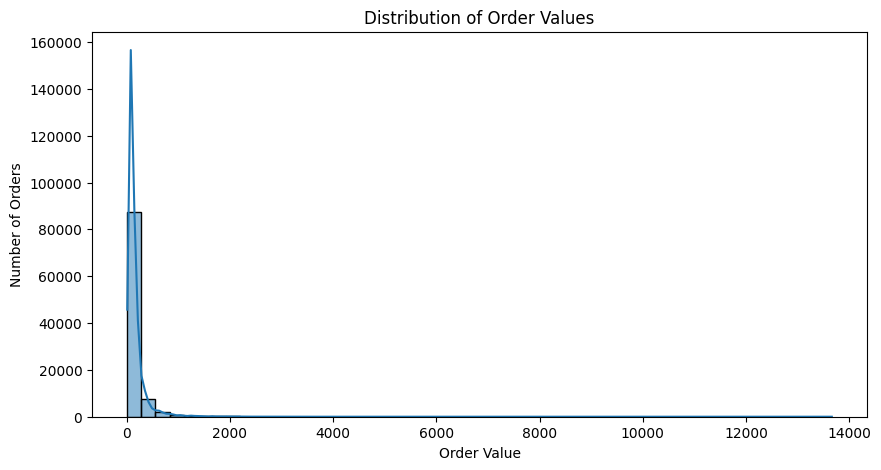

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    orders["order_value"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Order Values")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")

plt.show()

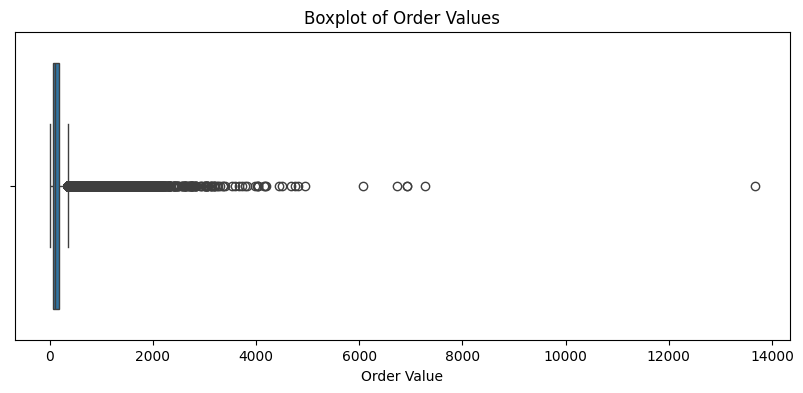

In [78]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=orders["order_value"])

plt.title("Boxplot of Order Values")
plt.xlabel("Order Value")

plt.show()

In [79]:
Q1 = orders["order_value"].quantile(0.25)
Q3 = orders["order_value"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = orders[
    (orders["order_value"] < lower_bound) |
    (orders["order_value"] > upper_bound)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))
print("Number of Outliers:", len(outliers))

Q1: 61.98
Q3: 176.87
IQR: 114.89
Lower Bound: -110.36
Upper Bound: 349.21
Number of Outliers: 7775


In [80]:
total_orders = orders["order_value"].notna().sum()

outlier_percentage = (
    len(outliers) / total_orders
) * 100

print("Total orders with value:", total_orders)
print("Outlier orders:", len(outliers))
print("Outlier percentage:", round(outlier_percentage, 2), "%")

Total orders with value: 98666
Outlier orders: 7775
Outlier percentage: 7.88 %


In [81]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

orders["shipping_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [82]:
# Make sure shipping_days exists in orders
orders["shipping_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

# Create orders + reviews dataset again
orders_reviews = orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

print("orders_reviews created successfully!")

display(
    orders_reviews[
        ["order_id", "shipping_days", "review_score"]
    ].head()
)

orders_reviews created successfully!


,order_id,shipping_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,5.0


In [83]:
shipping_review = orders_reviews[
    ["shipping_days", "review_score"]
].dropna()

print("Records available for correlation:", len(shipping_review))

Records available for correlation: 96359


In [84]:
correlation = shipping_review[
    "shipping_days"
].corr(
    shipping_review["review_score"]
)

print("Correlation between shipping time and review score:",
      round(correlation, 3))

Correlation between shipping time and review score: -0.334


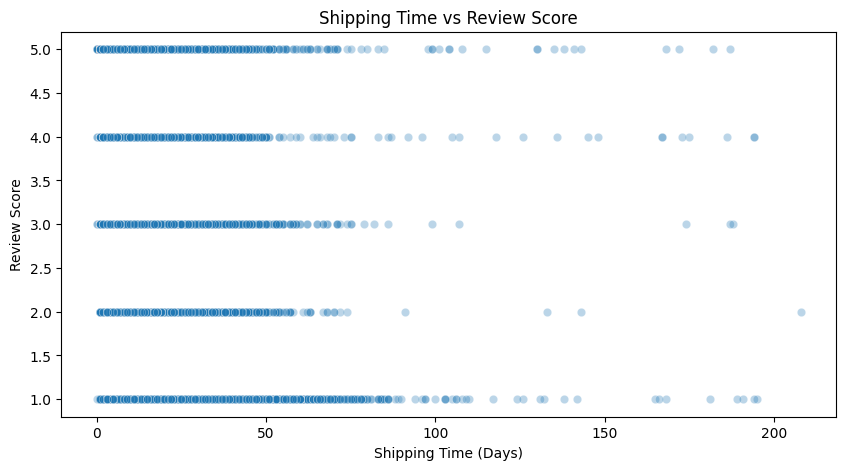

In [85]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=shipping_review,
    x="shipping_days",
    y="review_score",
    alpha=0.3
)

plt.title("Shipping Time vs Review Score")
plt.xlabel("Shipping Time (Days)")
plt.ylabel("Review Score")

plt.show()

In [86]:
shipping_summary = (
    shipping_review
    .groupby("shipping_days")["review_score"]
    .mean()
    .reset_index()
)

shipping_summary.head(10)

,shipping_days,review_score
0,0.0,4.230769
1,1.0,4.495547
2,2.0,4.478330
3,3.0,4.431169
4,4.0,4.425792
5,5.0,4.391761
6,6.0,4.381351
7,7.0,4.375360
8,8.0,4.353612
9,9.0,4.304031


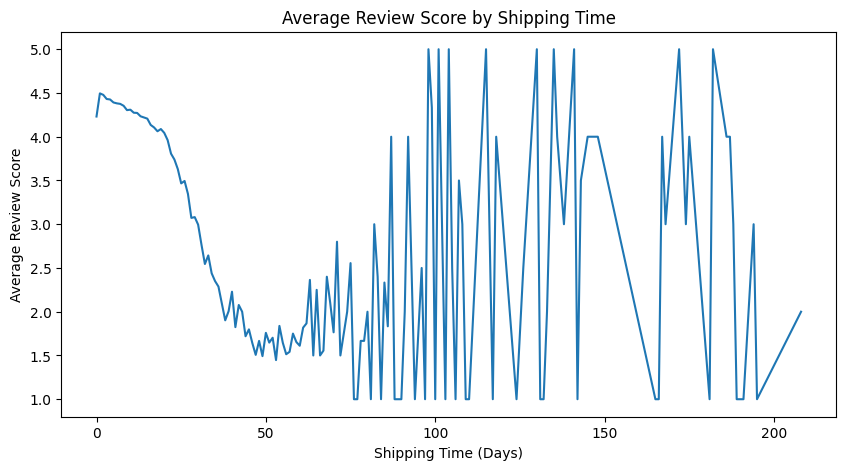

In [87]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=shipping_summary,
    x="shipping_days",
    y="review_score"
)

plt.title("Average Review Score by Shipping Time")
plt.xlabel("Shipping Time (Days)")
plt.ylabel("Average Review Score")

plt.show()

In [88]:
print("========== EDA SUMMARY ==========")

print("\n1. ORDER VALUE")
print("Average order value:",
      round(orders["order_value"].mean(), 2))

print("Median order value:",
      round(orders["order_value"].median(), 2))

print("Maximum order value:",
      round(orders["order_value"].max(), 2))

print("\n2. OUTLIERS")
print("Number of outliers:", len(outliers))
print("Outlier percentage:",
      round(outlier_percentage, 2), "%")

print("\n3. SHIPPING VS REVIEW")
print("Correlation:",
      round(correlation, 3))

========== EDA SUMMARY ==========

1. ORDER VALUE
Average order value: 160.58
Median order value: 105.29
Maximum order value: 13664.08

2. OUTLIERS
Number of outliers: 7775
Outlier percentage: 7.88 %

3. SHIPPING VS REVIEW
Correlation: -0.334


In [89]:
from scipy import stats
import numpy as np

# Remove missing order values
order_values = orders["order_value"].dropna()

# Sample statistics
n = len(order_values)
mean_order_value = order_values.mean()
std_order_value = order_values.std()

# Standard Error
standard_error = std_order_value / np.sqrt(n)

# 95% Confidence Interval
confidence_level = 0.95
alpha = 1 - confidence_level

t_critical = stats.t.ppf(
    1 - alpha / 2,
    df=n - 1
)

margin_of_error = t_critical * standard_error

lower_ci = mean_order_value - margin_of_error
upper_ci = mean_order_value + margin_of_error

print("===== 95% CONFIDENCE INTERVAL =====")
print("Number of orders:", n)
print("Average Order Value:", round(mean_order_value, 2))
print("Lower Bound:", round(lower_ci, 2))
print("Upper Bound:", round(upper_ci, 2))

===== 95% CONFIDENCE INTERVAL =====
Number of orders: 98666
Average Order Value: 160.58
Lower Bound: 159.2
Upper Bound: 161.95


In [90]:
orders["purchase_day"] = orders[
    "order_purchase_timestamp"
].dt.day_name()

orders["day_type"] = np.where(
    orders["purchase_day"].isin(["Saturday", "Sunday"]),
    "Weekend",
    "Weekday"
)

print(orders["day_type"].value_counts())

day_type
Weekday    76594
Weekend    22847
Name: count, dtype: int64


In [91]:
day_type_counts = (
    orders
    .groupby("day_type")
    .size()
    .reset_index(name="order_count")
)

display(day_type_counts)

,day_type,order_count
0,Weekday,76594
1,Weekend,22847


In [92]:
total = day_type_counts["order_count"].sum()

day_type_counts["percentage"] = (
    day_type_counts["order_count"] / total * 100
)

display(day_type_counts)

,day_type,order_count,percentage
0,Weekday,76594,77.024567
1,Weekend,22847,22.975433


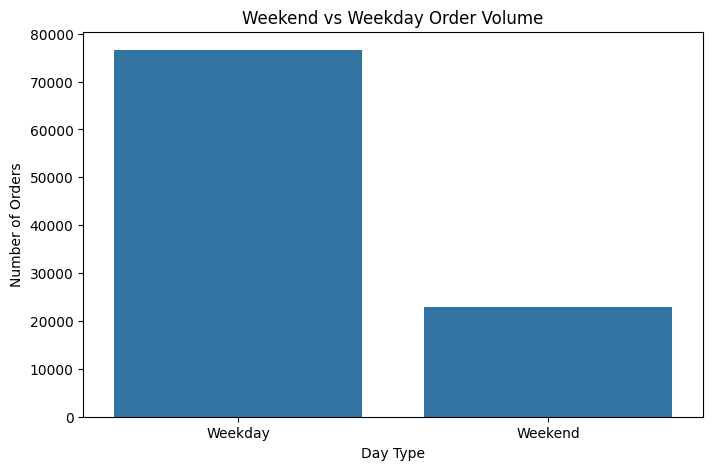

In [93]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=day_type_counts,
    x="day_type",
    y="order_count"
)

plt.title("Weekend vs Weekday Order Volume")
plt.xlabel("Day Type")
plt.ylabel("Number of Orders")

plt.show()

In [94]:
weekday_orders = orders[
    orders["day_type"] == "Weekday"
].shape[0]

weekend_orders = orders[
    orders["day_type"] == "Weekend"
].shape[0]

print("===== WEEKEND VS WEEKDAY =====")
print("Weekday orders:", weekday_orders)
print("Weekend orders:", weekend_orders)

if weekday_orders > weekend_orders:
    print("Finding: Weekday order volume is higher.")
elif weekend_orders > weekday_orders:
    print("Finding: Weekend order volume is higher.")
else:
    print("Finding: Weekend and weekday order volumes are equal.")

===== WEEKEND VS WEEKDAY =====
Weekday orders: 76594
Weekend orders: 22847
Finding: Weekday order volume is higher.


In [95]:
from scipy.stats import chi2_contingency

# Observed order counts
observed = np.array([
    weekday_orders,
    weekend_orders
])

# Expected counts assuming equal order volume
expected = np.array([
    observed.sum() / 2,
    observed.sum() / 2
])

chi_square = np.sum(
    (observed - expected) ** 2 / expected
)

p_value = 1 - stats.chi2.cdf(
    chi_square,
    df=1
)

print("===== HYPOTHESIS TEST =====")
print("Chi-square statistic:", round(chi_square, 4))
print("P-value:", round(p_value, 4))

===== HYPOTHESIS TEST =====
Chi-square statistic: 29049.7884
P-value: 0.0


In [96]:
alpha = 0.05

print("Significance level:", alpha)

if p_value < alpha:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference")
    print("between weekday and weekend order volume.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence of a statistically")
    print("significant difference between weekday and weekend order volume.")

Significance level: 0.05
Result: Reject the null hypothesis.
There is a statistically significant difference
between weekday and weekend order volume.


In [97]:
print("========================================")
print("       E-COMMERCE HEALTH CHECK")
print("          FINAL FINDINGS")
print("========================================")

print("\n1. ORDER VALUE")
print("Average Order Value:",
      round(mean_order_value, 2))

print("95% Confidence Interval:",
      round(lower_ci, 2),
      "to",
      round(upper_ci, 2))

print("Maximum Order Value:",
      round(orders["order_value"].max(), 2))

print("\n2. REPEAT CUSTOMERS")
print("Repeat Customer Rate:",
      round(
          repeat_rate["repeat_customer_rate"].iloc[0],
          2
      ),
      "%")

print("\n3. SHIPPING & CUSTOMER SATISFACTION")
print("Shipping Time vs Review Score Correlation:",
      round(correlation, 3))

print("\n4. WEEKEND VS WEEKDAY")
print("Weekday Orders:", weekday_orders)
print("Weekend Orders:", weekend_orders)

print("\n5. OUTLIERS")
print("Outlier Orders:", len(outliers))
print("Outlier Percentage:",
      round(outlier_percentage, 2),
      "%")

print("\n6. HYPOTHESIS TEST")
print("Chi-square:", round(chi_square, 4))
print("P-value:", round(p_value, 4))

       E-COMMERCE HEALTH CHECK
          FINAL FINDINGS

1. ORDER VALUE
Average Order Value: 160.58
95% Confidence Interval: 159.2 to 161.95
Maximum Order Value: 13664.08

2. REPEAT CUSTOMERS
Repeat Customer Rate: 3.12 %

3. SHIPPING & CUSTOMER SATISFACTION
Shipping Time vs Review Score Correlation: -0.334

4. WEEKEND VS WEEKDAY
Weekday Orders: 76594
Weekend Orders: 22847

5. OUTLIERS
Outlier Orders: 7775
Outlier Percentage: 7.88 %

6. HYPOTHESIS TEST
Chi-square: 29049.7884
P-value: 0.0


In [98]:
print("===== BUSINESS RECOMMENDATION =====")

if correlation < 0:
    print(
        "Recommendation: Focus on reducing delivery time because "
        "longer shipping times are associated with lower review scores."
    )
else:
    print(
        "Recommendation: Continue monitoring delivery performance "
        "because shipping time does not show a strong negative "
        "relationship with review scores."
    )

if repeat_rate["repeat_customer_rate"].iloc[0] < 10:
    print(
        "The retailer should consider loyalty programs, "
        "personalized offers, and post-purchase engagement "
        "to improve repeat purchases."
    )

===== BUSINESS RECOMMENDATION =====
Recommendation: Focus on reducing delivery time because longer shipping times are associated with lower review scores.
The retailer should consider loyalty programs, personalized offers, and post-purchase engagement to improve repeat purchases.


# E-Commerce Health Check — Olist

## 1. Objective

The objective of this analysis was to evaluate the health of an online retail operation using the Brazilian E-Commerce Public Dataset by Olist. The analysis focused on order value, product revenue, repeat customers, delivery performance, customer satisfaction, and order trends.

## 2. Key Findings

### Finding 1 — Order Value

The average order value was 160.58, with a 95% confidence interval of 159.2 to 161.95.

### Finding 2 — Repeat Customers

The repeat customer rate was 3.12%, indicating an opportunity to improve customer retention and encourage repeat purchases.

### Finding 3 — Delivery and Customer Satisfaction

The correlation between shipping time and review score was -0.334, suggesting a moderate negative relationship between delivery speed and customer satisfaction.

### Finding 4 — Weekend vs Weekday

There were 76594 weekday orders** compared with 22847 weekend orders**.

### Finding 5 — Outliers

The analysis identified 7775 potential order-value outliers, representing approximately 7.88 % of orders.

## 3. Business Recommendation

The retailer should prioritize delivery performance and customer retention. Reducing delivery delays can help improve customer satisfaction when longer shipping times are associated with lower review scores. The retailer should also consider loyalty programs, personalized promotions, and post-purchase engagement to encourage repeat purchases. High-value orders should be monitored separately because they can significantly affect revenue metrics.

## 4. Conclusion

The E-Commerce Health Check provided insights into product revenue, customer retention, order-value patterns, delivery performance, and customer satisfaction. These findings can help the retailer identify operational weaknesses and opportunities for improving customer experience and business performance.